<h1>1. Imports and Notebook Setup</h1>

In [1]:
import os
import warnings

import joblib
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings("ignore")
np.random.seed(42)

sns.set_theme(style="whitegrid", palette="Set2")

<h1>2. Data Loading</h1>

In [2]:
# Download dataset from Kaggle Hub
dataset_path = kagglehub.dataset_download(
    "imakash3011/customer-personality-analysis"
)

# Load dataset
csv_path = os.path.join(dataset_path, "marketing_campaign.csv")
df = pd.read_csv(csv_path, sep="\t")

# Remove columns not required for preprocessing
df.drop(columns=["ID"], inplace=True, errors="ignore")

# Convert customer enrollment date to datetime
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y"
)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (2240, 28)


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,5,0,0,0,0,0,0,3,11,0


<h1>3. Feature Engineering</h1>

In [3]:
reference_date = df["Dt_Customer"].max()
df["Tenure"] = (reference_date - df["Dt_Customer"]).dt.days
reference_year = reference_date.year
df["Age"] = reference_year - df["Year_Birth"]
df["Children"] = df["Kidhome"] + df["Teenhome"]

spouse_map = {
    "Married": 2,
    "Together": 2,
    "Single": 1,
    "Divorced": 1,
    "Widow": 1,
    "Alone": 1,
    "Absurd": 1,
    "YOLO": 1,
}
df["Family_Size"] = df["Marital_Status"].map(spouse_map) + df["Children"]

spend_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
]
df["Total_Spending"] = df[spend_cols].sum(axis=1)

purchase_cols = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

# Ratios are more comparable than raw channel purchase counts.
df["Web_Purchase_Ratio"] = df["NumWebPurchases"].div(df["Total_Purchases"]).fillna(0)
df["Store_Purchase_Ratio"] = df["NumStorePurchases"].div(df["Total_Purchases"]).fillna(0)
df["Catalog_Purchase_Ratio"] = (
    df["NumCatalogPurchases"].div(df["Total_Purchases"]).fillna(0)
)

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response",
]
df["Campaign_Acceptance_Count"] = df[campaign_cols].sum(axis=1)

for col in spend_cols:
    share_name = col.replace("Mnt", "") + "_Share"
    df[share_name] = df[col].div(df["Total_Spending"]).fillna(0)

display(df.head())

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Web_Purchase_Ratio,Store_Purchase_Ratio,Catalog_Purchase_Ratio,Campaign_Acceptance_Count,Wines_Share,Fruits_Share,MeatProducts_Share,FishProducts_Share,SweetProducts_Share,GoldProds_Share
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,0.363636,0.181818,0.454545,1,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,0.250000,0.500000,0.250000,0,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,0.400000,0.500000,0.100000,0,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0.333333,0.666667,0.000000,0,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,0.357143,0.428571,0.214286,0,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545


<h1>4. Data Cleaning and Exploratory Analysis</h1>

Cleaned dataset shape: (2212, 22)
Cleaned Dataset Shape: (2212, 22)
<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Education                  2212 non-null   int64  
 1   Income                     2212 non-null   float64
 2   Recency                    2212 non-null   int64  
 3   NumDealsPurchases          2212 non-null   int64  
 4   NumWebVisitsMonth          2212 non-null   int64  
 5   Complain                   2212 non-null   int64  
 6   Tenure                     2212 non-null   int64  
 7   Age                        2212 non-null   int64  
 8   Children                   2212 non-null   int64  
 9   Family_Size                2212 non-null   int64  
 10  Total_Spending             2212 non-null   int64  
 11  Total_Purchases            2212 non-null   int64  
 12  Web_Purchase_Ratio         2212 non-null 

,Education,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,Tenure,Age,Children,Family_Size,...,Web_Purchase_Ratio,Store_Purchase_Ratio,Catalog_Purchase_Ratio,Campaign_Acceptance_Count,Wines_Share,Fruits_Share,MeatProducts_Share,FishProducts_Share,SweetProducts_Share,GoldProds_Share
0,2,58138.0,58,3,7,0,663,57,0,1,...,0.363636,0.181818,0.454545,1,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422
1,2,46344.0,38,2,5,0,113,60,2,3,...,0.250000,0.500000,0.250000,0,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222
2,2,71613.0,26,1,4,0,312,49,0,2,...,0.400000,0.500000,0.100000,0,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124
3,2,26646.0,26,2,6,0,139,30,1,3,...,0.333333,0.666667,0.000000,0,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340
4,4,58293.0,94,5,5,0,161,33,1,3,...,0.357143,0.428571,0.214286,0,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545


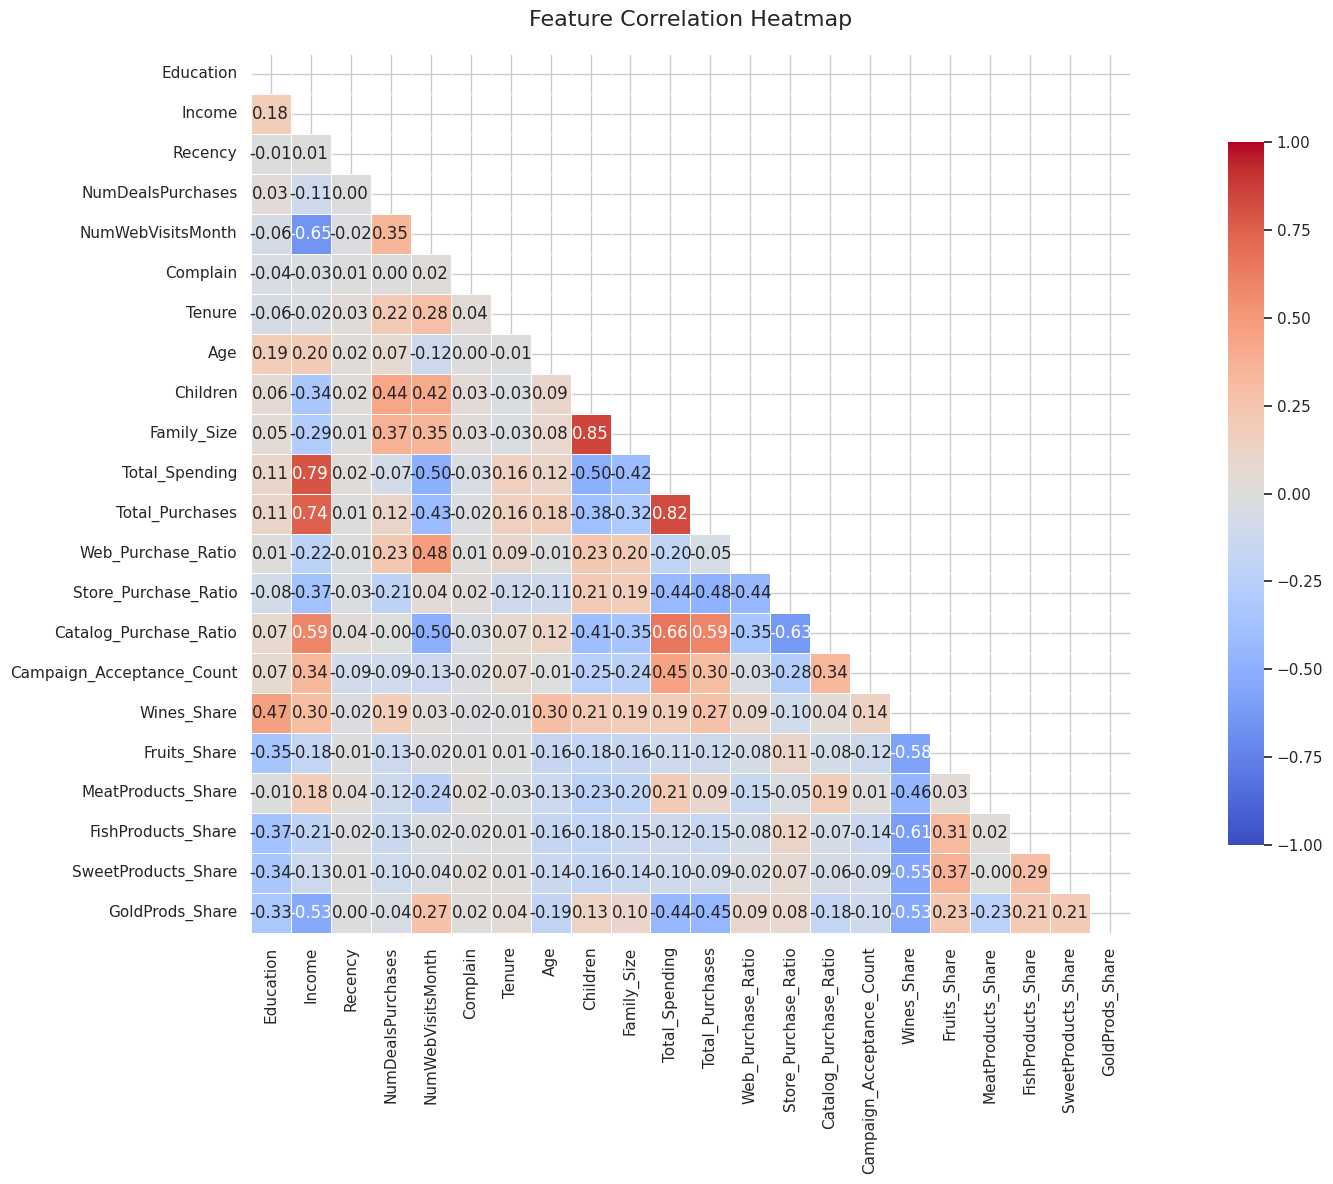

In [4]:
education_map = {
    "Basic": 0,
    "2n Cycle": 1,
    "Graduation": 2,
    "Master": 3,
    "PhD": 4,
}
df["Education"] = df["Education"].map(education_map)

columns_to_drop = [
    "Year_Birth",
    "Kidhome",
    "Teenhome",
    "Marital_Status",
    "Dt_Customer",
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response",
    "Z_CostContact",
    "Z_Revenue",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
]
df = df.drop(columns=columns_to_drop, errors="ignore")
df = df.dropna(subset=["Income"]).copy()

q1 = df["Income"].quantile(0.25)
q3 = df["Income"].quantile(0.75)
iqr = q3 - q1
income_upper_bound = q3 + 3.0 * iqr

# Use a wider IQR fence because the high-income customers may be real premium buyers.
df = df[(df["Income"] <= income_upper_bound) & (df["Age"] < 100)].copy()

print(f"Cleaned dataset shape: {df.shape}")
print(f"Cleaned Dataset Shape: {df.shape}")
df.info()
display(df.head())

plt.figure(figsize=(20, 12))
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Feature Correlation Heatmap", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("feature_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

<h1>5. Feature Scaling and K Selection</h1>

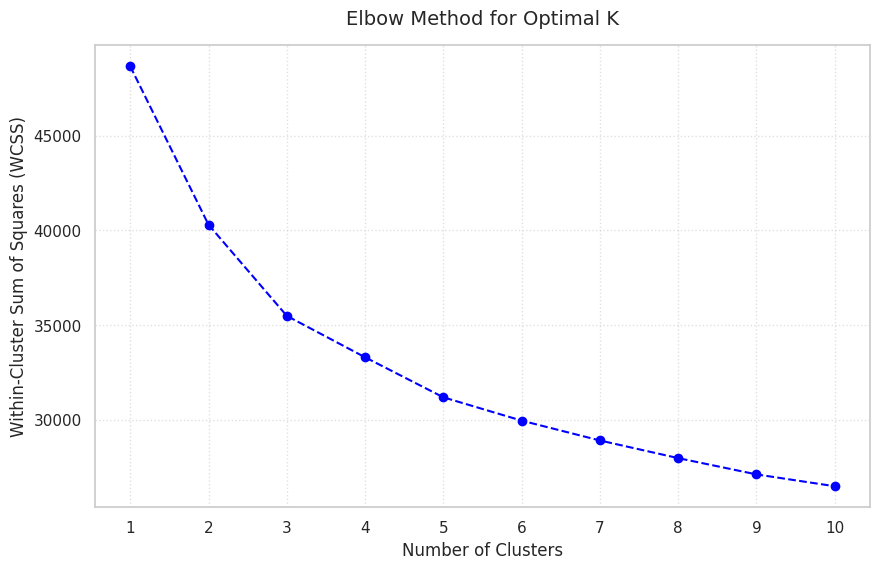

,K,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.166073,458.955108,2.044375
1,3,0.159428,410.363123,1.966679
2,4,0.130002,339.787467,2.143294
3,5,0.134414,309.413370,1.827318
4,6,0.121660,275.735600,1.952894
5,7,0.110696,251.336850,2.024691
6,8,0.103376,232.993737,2.084375
7,9,0.105880,218.979783,2.078236
8,10,0.106657,204.935976,2.144292
9,11,0.103987,193.450119,2.133219



Selected Number of Clusters: 3


In [5]:
feature_names = df.columns

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[feature_names])

wcss = []
cluster_range = range(1, 11)

for k in cluster_range:
    model = KMeans(n_clusters=k, init="k-means++", n_init=50, random_state=42)
    model.fit(scaled_features)
    wcss.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(cluster_range, wcss, marker="o", linestyle="--", color="b")
plt.title("Elbow Method for Optimal K", fontsize=14, pad=15)
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(cluster_range)
plt.grid(True, linestyle=":", alpha=0.6)
plt.savefig("elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

results = []
for k in range(2, 12):
    model = KMeans(n_clusters=k, init="k-means++", n_init=50, random_state=42)
    labels = model.fit_predict(scaled_features)
    sil = silhouette_score(scaled_features, labels)
    ch = calinski_harabasz_score(scaled_features, labels)
    db = davies_bouldin_score(scaled_features, labels)
    results.append({
        "K": k,
        "Silhouette": sil,
        "Calinski-Harabasz": ch,
        "Davies-Bouldin": db,
    })
results = pd.DataFrame(results)
display(results)
print("\nSelected Number of Clusters: 3")

<h1>6. Clustering Models</h1>

K-Means Cluster Distribution
Cluster 0: 924 customers (41.77%)
Cluster 1: 676 customers (30.56%)
Cluster 2: 612 customers (27.67%)

K-Means Cluster Profile


,Income,Total_Spending,Total_Purchases,Age,Family_Size,Children,Campaign_Acceptance_Count,Wines_Share,MeatProducts_Share
Cluster,,,,,,,,,
0,49482.80,418.14,11.70,48.06,3.10,1.42,0.30,0.63,0.20
1,74661.31,1306.01,19.49,46.52,1.88,0.28,0.92,0.45,0.32
2,30620.49,121.01,6.22,39.01,2.61,0.97,0.15,0.21,0.26


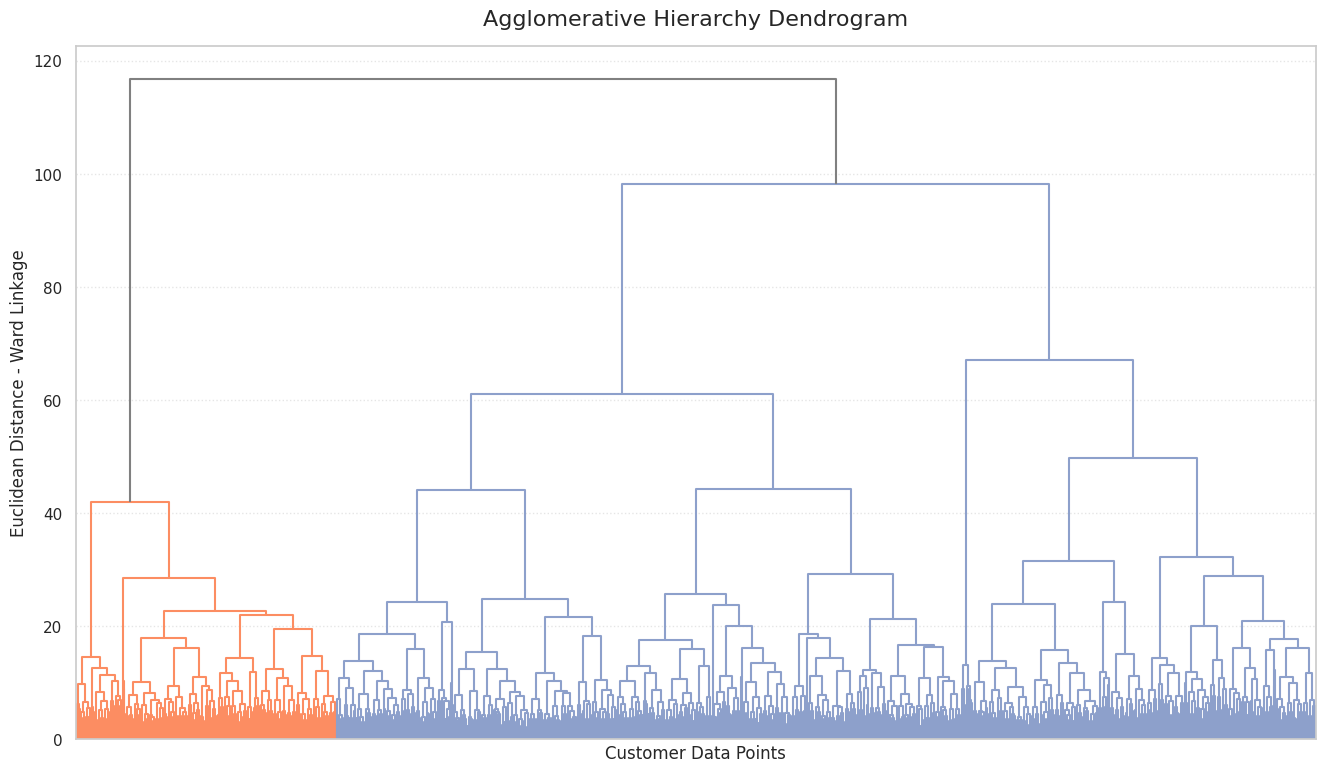

Agglomerative Cluster Distribution
Cluster 0: 631 customers (28.53%)
Cluster 1: 465 customers (21.02%)
Cluster 2: 1116 customers (50.45%)

Agglomerative Cluster Profile


,Income,Total_Spending,Total_Purchases,Age,Family_Size,Children,Campaign_Acceptance_Count,Wines_Share,MeatProducts_Share
Agg_Cluster,,,,,,,,,
0,30277.76,114.37,6.04,38.83,2.67,1.01,0.18,0.24,0.26
1,77024.16,1389.37,19.09,45.75,1.65,0.05,1.08,0.42,0.34
2,53773.65,560.09,13.54,48.35,2.95,1.28,0.34,0.60,0.20


,Algorithm,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,0.159428,410.363123,1.966679
1,Agglomerative,0.135552,347.133754,2.152446



Final Model Selection: K-Means was selected because it achieved higher Silhouette and Calinski-Harabasz scores and a lower Davies-Bouldin index than Agglomerative Clustering.


In [6]:
profile_metrics = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Age",
    "Family_Size",
    "Children",
    "Campaign_Acceptance_Count",
    "Wines_Share",
    "MeatProducts_Share",
]

final_kmeans = KMeans(n_clusters=3, init="k-means++", n_init=50, random_state=42)
df["Cluster"] = final_kmeans.fit_predict(scaled_features)

print("K-Means Cluster Distribution")
counts = df["Cluster"].value_counts().sort_index()
proportions = df["Cluster"].value_counts(normalize=True).sort_index() * 100

for cluster_id in counts.index:
    print(f"Cluster {cluster_id}: {counts[cluster_id]} customers ({proportions[cluster_id]:.2f}%)")

print("\nK-Means Cluster Profile")
display(df.groupby("Cluster")[profile_metrics].mean().round(2))
kmeans_sil = silhouette_score(scaled_features, df["Cluster"])
kmeans_ch = calinski_harabasz_score(scaled_features, df["Cluster"])
kmeans_db = davies_bouldin_score(scaled_features, df["Cluster"])

linkage_matrix = linkage(scaled_features, method="ward")

plt.figure(figsize=(16, 9))
dendrogram(
    linkage_matrix,
    no_labels=True,
    color_threshold=110,
    above_threshold_color="grey",
)
plt.title("Agglomerative Hierarchy Dendrogram", fontsize=16, pad=15)
plt.xlabel("Customer Data Points")
plt.ylabel("Euclidean Distance - Ward Linkage")
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.savefig(
    "agglomerative_dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

agg_model = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
df["Agg_Cluster"] = agg_model.fit_predict(scaled_features)

print("Agglomerative Cluster Distribution")
agg_counts = df["Agg_Cluster"].value_counts().sort_index()
agg_proportions = df["Agg_Cluster"].value_counts(normalize=True).sort_index() * 100

for cluster_id in agg_counts.index:
    print(f"Cluster {cluster_id}: {agg_counts[cluster_id]} customers ({agg_proportions[cluster_id]:.2f}%)")

print("\nAgglomerative Cluster Profile")
display(df.groupby("Agg_Cluster")[profile_metrics].mean().round(2))

agg_sil = silhouette_score(scaled_features, df["Agg_Cluster"])
agg_ch = calinski_harabasz_score(scaled_features, df["Agg_Cluster"])
agg_db = davies_bouldin_score(scaled_features, df["Agg_Cluster"])

comparison = pd.DataFrame(
    {
        "Algorithm": ["K-Means", "Agglomerative"],
        "Silhouette": [kmeans_sil, agg_sil],
        "Calinski-Harabasz": [kmeans_ch, agg_ch],
        "Davies-Bouldin": [kmeans_db, agg_db],
    }
)

display(comparison)

print(
    "\nFinal Model Selection: "
    "K-Means was selected because it achieved higher "
    "Silhouette and Calinski-Harabasz scores and a lower "
    "Davies-Bouldin index than Agglomerative Clustering."
)

df.drop(columns="Agg_Cluster", inplace=True)

<h1>7. Customer Segment Visualization</h1>

Customer Segment Distribution
Customer_Segment
Family Shoppers      924
Premium Customers    676
Budget Shoppers      612
Name: count, dtype: int64



,Income,Total_Spending,Total_Purchases,Recency,Campaign_Acceptance_Count,Age,Family_Size
Customer_Segment,,,,,,,
Budget Shoppers,30620.49,121.01,6.22,50.06,0.15,39.01,2.61
Family Shoppers,49482.80,418.14,11.70,47.38,0.30,48.06,3.10
Premium Customers,74661.31,1306.01,19.49,50.32,0.92,46.52,1.88


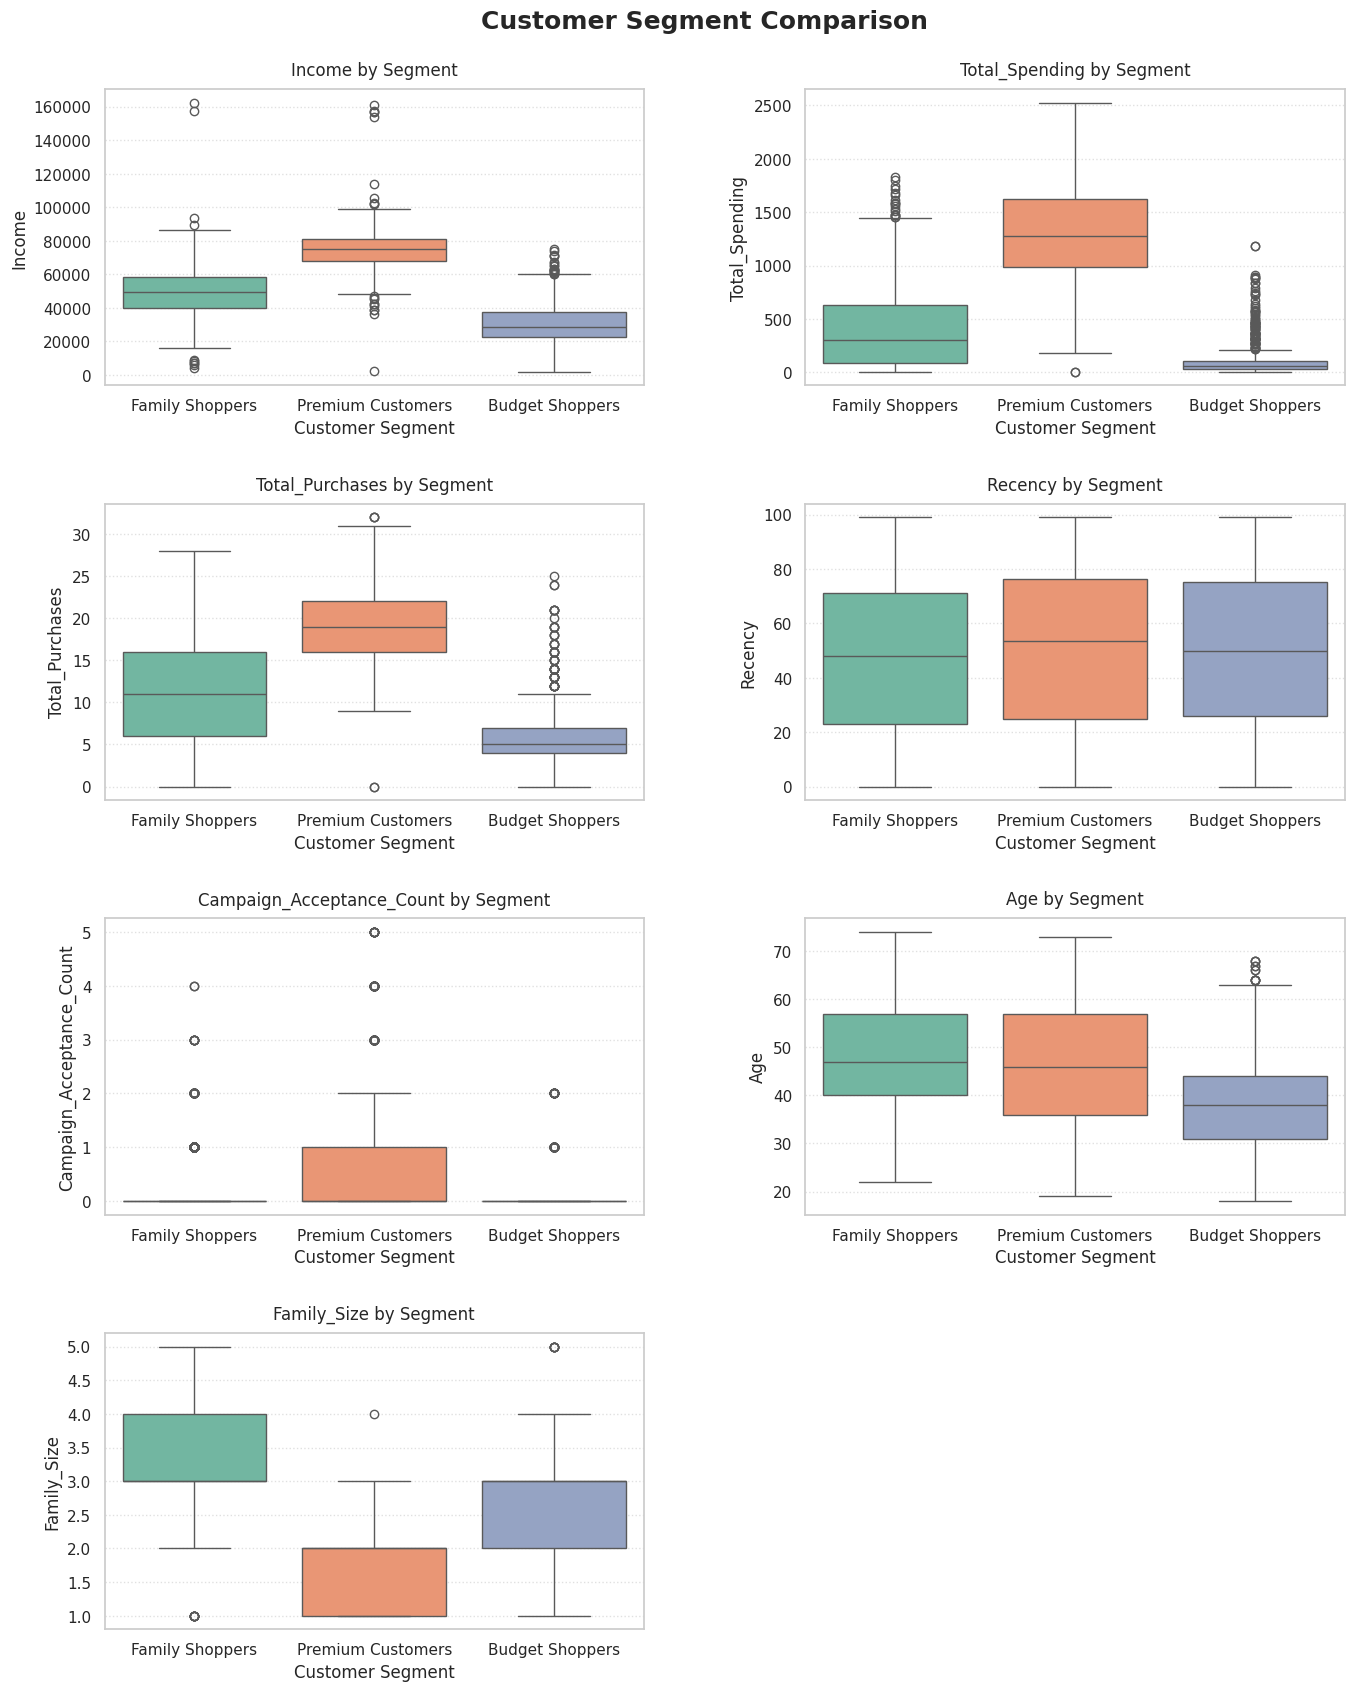

Total Explained Variance: 38.96%


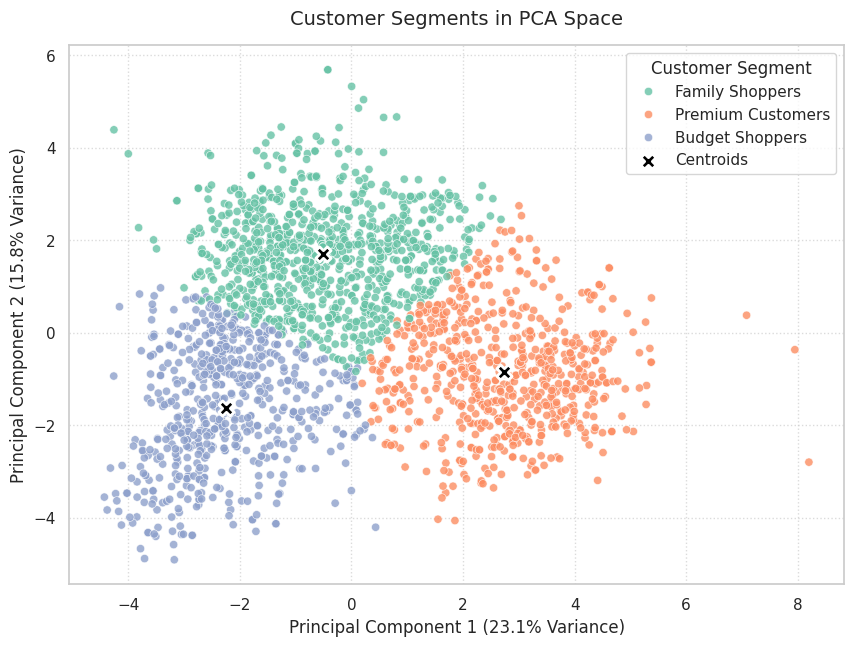

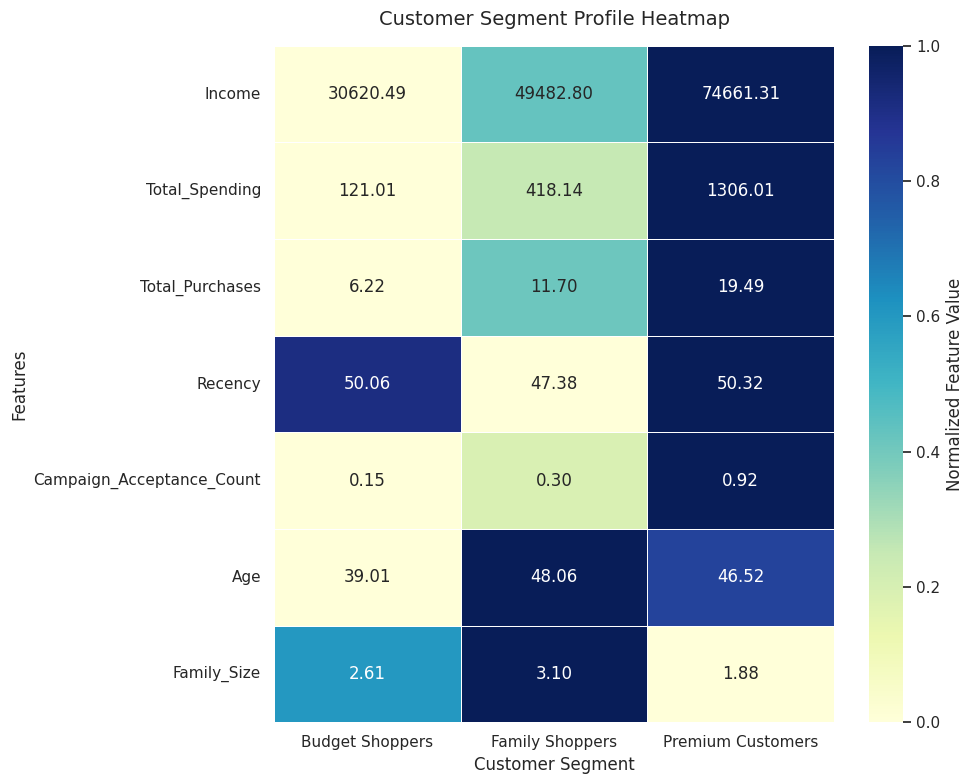

Note: Cell colors represent normalized feature values, while annotations display the original cluster means.


In [7]:
segment_map = {
    0: "Family Shoppers",
    1: "Premium Customers",
    2: "Budget Shoppers",
}

segment_order = list(segment_map.values())

# Map cluster IDs to business-friendly names
df["Customer_Segment"] = df["Cluster"].map(segment_map)

print("Customer Segment Distribution")
print(df["Customer_Segment"].value_counts())
print()

# Features used for customer profiling
profile_features = [
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Recency",
    "Campaign_Acceptance_Count",
    "Age",
    "Family_Size",
]

# Display cluster summary
cluster_profile = (
    df.groupby("Customer_Segment")[profile_features]
    .mean()
    .round(2)
)

display(cluster_profile)

# ==========================================================
# Cluster-wise Feature Comparison
# ==========================================================

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

for i, feature in enumerate(profile_features):
    sns.boxplot(
        data=df,
        x="Customer_Segment",
        y=feature,
        order=segment_order,
        palette="Set2",
        ax=axes[i],
    )

    axes[i].set_title(f"{feature} by Segment", fontsize=12, pad=10)
    axes[i].set_xlabel("Customer Segment")
    axes[i].set_ylabel(feature)
    axes[i].grid(axis="y", linestyle=":", alpha=0.6)

# Remove the unused subplot
fig.delaxes(axes[-1])

plt.suptitle(
    "Customer Segment Comparison",
    fontsize=18,
    weight="bold",
    y=0.92,
)

plt.subplots_adjust(hspace=0.4, wspace=0.3)

plt.savefig(
    "customer_segment_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ==========================================================
# PCA Visualization
# ==========================================================

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

df["PCA1"] = pca_features[:, 0]
df["PCA2"] = pca_features[:, 1]

explained = pca.explained_variance_ratio_

print(
    f"Total Explained Variance: "
    f"{explained.sum() * 100:.2f}%"
)

# Transform cluster centroids into PCA space
centers_pca = pca.transform(final_kmeans.cluster_centers_)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Customer_Segment",
    hue_order=segment_order,
    palette="Set2",
    alpha=0.8,
)

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker="X",
    s=120,
    c="black",
    edgecolor="white",
    linewidth=2,
    label="Centroids",
    zorder=5,
)

plt.title(
    "Customer Segments in PCA Space",
    fontsize=14,
    pad=15,
)

plt.xlabel(
    f"Principal Component 1 ({explained[0] * 100:.1f}% Variance)"
)

plt.ylabel(
    f"Principal Component 2 ({explained[1] * 100:.1f}% Variance)"
)

plt.legend(title="Customer Segment")
plt.grid(True, linestyle=":", alpha=0.7)

plt.savefig(
    "customer_segments_pca.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# ==========================================================
# Cluster Profile Heatmap
# ==========================================================

cluster_profile_normalized = (
    cluster_profile - cluster_profile.min()
) / (
    cluster_profile.max() - cluster_profile.min()
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cluster_profile_normalized.T,
    annot=cluster_profile.T,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Normalized Feature Value"},
)

plt.title(
    "Customer Segment Profile Heatmap",
    fontsize=14,
    pad=15,
)

plt.xlabel("Customer Segment")
plt.ylabel("Features")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "customer_segment_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Note: Cell colors represent normalized feature values, "
    "while annotations display the original cluster means."
)

<h1>8. Business Recommendations and Model Export</h1>

In [8]:
personas_data = {
    "Segment": ["Family Shoppers", "Premium Customers", "Budget Shoppers"],
    "Profile": [
        "Moderate income, larger households",
        "High income, high spending",
        "Younger, lower-income customers",
    ],
    "Behavior": [
        "Consistent purchasing behavior with larger household needs.",
        "High purchasing activity and strong campaign engagement.",
        "Value-conscious customers with lower purchase frequency.",
    ],
    "Core Strategy": [
        "Value maximization and retention",
        "LTV optimization and VIP exclusivity",
        "Cost-efficient inventory clearance",
    ],
    "Actionable Recommendations": [
        "1. Offer family-sized bundles and bulk purchase discounts.\n"
        "2. Use loyalty rewards for repeat purchases.\n"
        "3. Promote categories they already buy frequently.",
        "1. Enroll customers into a VIP rewards tier.\n"
        "2. Provide early access to premium products and limited editions.\n"
        "3. Use personalized offers with a premium-service tone.",
        "1. Focus outreach on clearance events and seasonal offers.\n"
        "2. Prefer low-cost digital channels over catalog campaigns.\n"
        "3. Avoid high-frequency campaigns that can reduce margin.",
    ],
}

customer_segmentation_matrix = pd.DataFrame(personas_data)
display(
    customer_segmentation_matrix.style.set_properties(
        **{"text-align": "left", "white-space": "pre-wrap", "vertical-align": "top"}
    ).set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
)

model_artifacts = {
    "kmeans": final_kmeans,
    "scaler": scaler,
    "pca": pca,
    "feature_names": feature_names,
    "segment_map": segment_map,
    "cluster_profile": cluster_profile,
    "customer_personas": customer_segmentation_matrix,
}

joblib.dump(model_artifacts, "customer_segmentation_model.pkl")

print("Model artifacts successfully saved to 'customer_segmentation_model.pkl'")
loaded_artifacts = joblib.load("customer_segmentation_model.pkl")

print("Saved Components:")
for key in loaded_artifacts:
    print(f"• {key}")

,Segment,Profile,Behavior,Core Strategy,Actionable Recommendations
0,Family Shoppers,"Moderate income, larger households",Consistent purchasing behavior with larger household needs.,Value maximization and retention,1. Offer family-sized bundles and bulk purchase discounts. 2. Use loyalty rewards for repeat purchases. 3. Promote categories they already buy frequently.
1,Premium Customers,"High income, high spending",High purchasing activity and strong campaign engagement.,LTV optimization and VIP exclusivity,1. Enroll customers into a VIP rewards tier. 2. Provide early access to premium products and limited editions. 3. Use personalized offers with a premium-service tone.
2,Budget Shoppers,"Younger, lower-income customers",Value-conscious customers with lower purchase frequency.,Cost-efficient inventory clearance,1. Focus outreach on clearance events and seasonal offers. 2. Prefer low-cost digital channels over catalog campaigns. 3. Avoid high-frequency campaigns that can reduce margin.


Model artifacts successfully saved to 'customer_segmentation_model.pkl'
Saved Components:
• kmeans
• scaler
• pca
• feature_names
• segment_map
• cluster_profile
• customer_personas
